In [23]:
# Google Colab Installation
!pip install tensorflow
!pip install onnx
!pip install onnxruntime
!pip install tf2onnx
!pip install apache-tvm
!pip install numpy pandas matplotlib seaborn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 46.1 MB/s eta 0:00:00


In [52]:
!pip install onnxsim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 46.3 MB/s eta 0:00:00


In [24]:
# Load Dataset
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = data.data
y = data.target

print(X.shape)

(569, 30)


In [25]:
# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
# Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
# Reshape for CNN
X_train_cnn = X_train.reshape(-1,6,5,1)
X_test_cnn = X_test.reshape(-1,6,5,1)

print(X_train_cnn.shape)

(455, 6, 5, 1)


In [31]:
# Build CNN

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

cnn = Sequential([

    Conv2D(
        32,
        (3,3),
        activation="relu",
        padding="same",
        input_shape=(6,5,1)
    ),

    Flatten(),

    Dense(
        64,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )

])

In [32]:
# Compile

cnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = cnn.fit(
    X_train_cnn,
    y_train,
    epochs=50,
    validation_split=0.2,
    batch_size=32
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 143ms/step - accuracy: 0.8929 - loss: 0.3875 - val_accuracy: 0.9341 - val_loss: 0.1705
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9478 - loss: 0.1363 - val_accuracy: 0.9780 - val_loss: 0.0853
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9725 - loss: 0.0853 - val_accuracy: 0.9890 - val_loss: 0.0617
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9780 - loss: 0.0709 - val_accuracy: 0.9890 - val_loss: 0.0398
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9863 - loss: 0.0618 - val_accuracy: 0.9890 - val_loss: 0.0402
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9890 - loss: 0.0576 - val_accuracy: 0.9890 - val_loss: 0.0383
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9890 - loss: 0.0506 - val_accuracy: 0.9890 - val_loss: 0.0329
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9890 - loss: 0.0458 - val_accuracy: 0.9890 - val_los

# **Training Visualization**

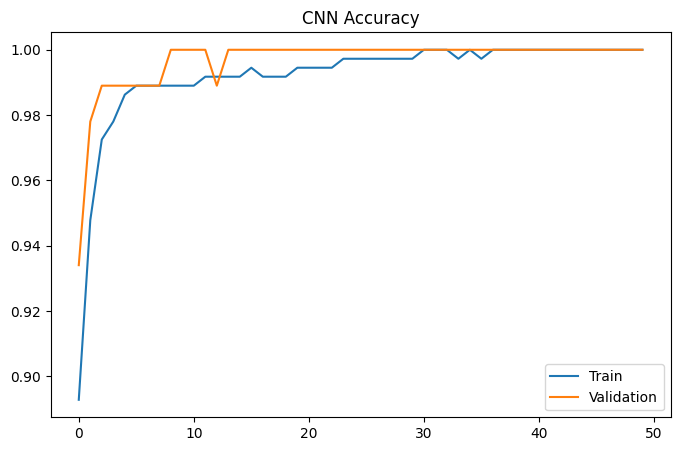

In [33]:
# Accuracy

plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"]
)

plt.plot(
    history.history["val_accuracy"]
)

plt.legend([
    "Train",
    "Validation"
])

plt.title(
    "CNN Accuracy"
)

plt.show()

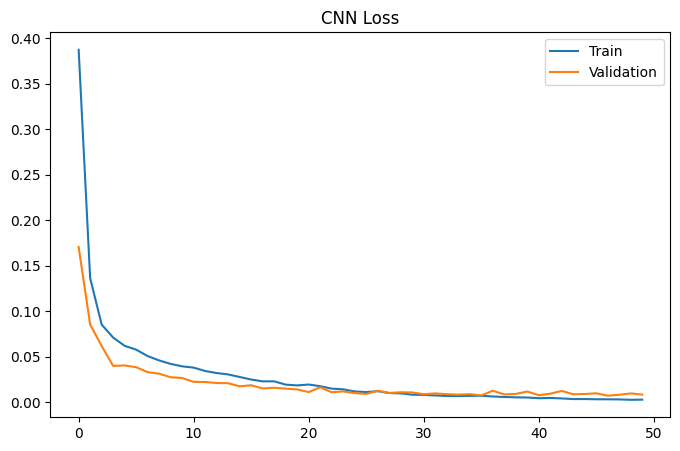

In [34]:
# Loss

plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"]
)

plt.plot(
    history.history["val_loss"]
)

plt.legend([
    "Train",
    "Validation"
])

plt.title(
    "CNN Loss"
)

plt.show()

In [35]:
# Evaluate CNN
pred_prob = cnn.predict(
    X_test_cnn
)

pred = (
    pred_prob > 0.5
).astype(int)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step


In [36]:
from sklearn.metrics import confusion_matrix
import numpy as np
tn, fp, fn, tp = confusion_matrix(
    y_test,
    pred
).ravel()
acc = (
    tp+tn
)/(tp+tn+fp+fn)

sen = tp/(tp+fn)

spec = tn/(tn+fp)

mcc = (
    (tp*tn)-(fp*fn)
)/np.sqrt(
    (tp+fp)*
    (tp+fn)*
    (tn+fp)*
    (tn+fn)
)

# **Confusion Matrix Visualization**

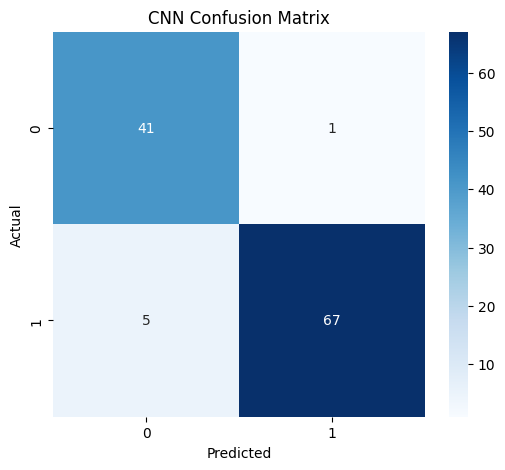

In [37]:
cm = confusion_matrix(
    y_test,
    pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "CNN Confusion Matrix"
)

plt.show()

# **Metrics Visualization**

In [38]:
metric_df = pd.DataFrame({

    "Metric":[
        "ACC",
        "SEN",
        "SPEC",
        "MCC"
    ],

    "Value":[
        acc,
        sen,
        spec,
        mcc
    ]

})

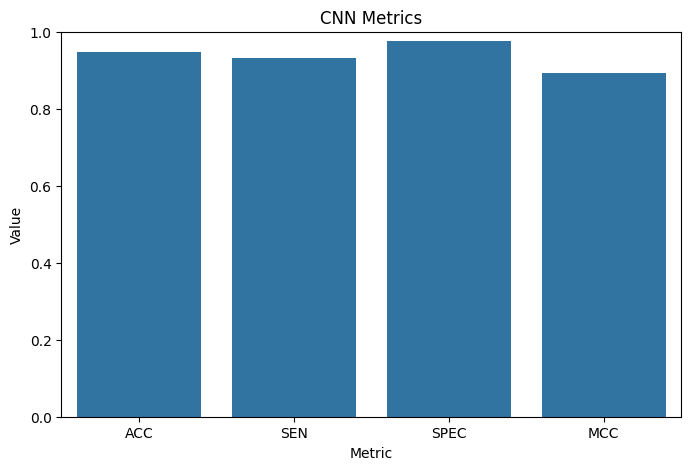

In [39]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=metric_df,
    x="Metric",
    y="Value"
)

plt.ylim(0,1)

plt.title(
    "CNN Metrics"
)

plt.show()

# **Export Keras → ONNX**

Untuk TensorFlow 2.20 + tf2onnx 1.17

In [40]:
import tensorflow as tf
import tf2onnx

In [41]:
@tf.function
def model_fn(x):
    return cnn(x)

In [42]:
onnx_model, _ = tf2onnx.convert.from_function(
    model_fn,
    input_signature=[
        tf.TensorSpec(
            [None,6,5,1],
            tf.float32,
            name="input"
        )
    ],
    opset=13
)

In [43]:
with open(
    "cancer_cnn.onnx",
    "wb"
) as f:

    f.write(
        onnx_model.SerializeToString()
    )

# **Verify ONNX**

In [44]:
import onnx

model = onnx.load(
    "cancer_cnn.onnx"
)

onnx.checker.check_model(
    model
)

print("ONNX valid")

ONNX valid


# **Check Operators**
Semua operator ini didukung oleh TVM Relax.

In [45]:
ops = set()

for node in model.graph.node:
    ops.add(node.op_type)

print(sorted(ops))

['Add', 'Cast', 'Concat', 'Conv', 'Gather', 'MatMul', 'Relu', 'Reshape', 'Shape', 'Sigmoid', 'Slice', 'Transpose']


# **ONNX Runtime Benchmark**

In [46]:
import onnxruntime as ort
import time

In [47]:
session = ort.InferenceSession(
    "cancer_cnn.onnx"
)

input_name = session.get_inputs()[0].name

In [48]:
start = time.time()

for _ in range(1000):

    session.run(
        None,
        {
            input_name:
            X_test_cnn[:1].astype(np.float32)
        }
    )

onnx_time = time.time() - start

In [51]:
import onnx

model = onnx.load(
    "cancer_cnn.onnx"
)

ops = {}

for node in model.graph.node:

    op = node.op_type

    ops[op] = ops.get(op,0)+1

print(ops)

{'Reshape': 2, 'Conv': 1, 'Relu': 2, 'Transpose': 1, 'Shape': 1, 'Gather': 1, 'Cast': 2, 'Slice': 1, 'Concat': 1, 'MatMul': 2, 'Add': 2, 'Sigmoid': 1}


# **Simplify ONNX Model (FIX TVM Shape/Slice ERROR)**

In [53]:
import onnx
from onnxsim import simplify

model = onnx.load("cancer_cnn.onnx")

model_simplified, check = simplify(model)

print("Simplified OK:", check)

Simplified OK: True


**Save Clean ONNX Model**

In [54]:
onnx.save(
    model_simplified,
    "cancer_cnn_simplified.onnx"
)

# **Verify Operators (VERY IMPORTANT)**

In [55]:
model = onnx.load("cancer_cnn_simplified.onnx")

ops = sorted(set(node.op_type for node in model.graph.node))
print(ops)

['Add', 'Conv', 'MatMul', 'Relu', 'Reshape', 'Sigmoid', 'Transpose']


**ONNX Runtime Benchmark (BASELINE)**

In [56]:
import onnxruntime as ort
import numpy as np
import time

session = ort.InferenceSession("cancer_cnn_simplified.onnx")

input_name = session.get_inputs()[0].name

sample = X_test_cnn[:1].astype(np.float32)

start = time.time()

for _ in range(1000):
    session.run(None, {input_name: sample})

onnx_time = time.time() - start

print("ONNX Runtime Time:", onnx_time)

ONNX Runtime Time: 0.03844738006591797


# **TVM RELAX IMPORT**

In [57]:
import tvm
from tvm import relax
from tvm.relax.frontend.onnx import from_onnx

print("TVM Version:", tvm.__version__)

TVM Version: 0.25.0rc0


# **Load Clean ONNX into TVM**

In [58]:
import onnx

model = onnx.load("cancer_cnn_simplified.onnx")

mod = from_onnx(model)

print(mod)

# from tvm.script import ir as I
# from tvm.script import tirx as T
# from tvm.tirx.layout import Axis
# from tvm.script import relax as R

@I.ir_module
class Module:
    @R.function
    def main(input: R.Tensor(("unk__32", 6, 5, 1), dtype="float32")) -> R.Tensor(("unk__32", 1), dtype="float32"):
        unk__32 = T.int64(is_size_var=True)
        R.func_attr({"num_input": 1})
        with R.dataflow():
            lv: R.Tensor((unk__32, 1, 6, 5), dtype="float32") = R.reshape(input, R.shape([unk__32, 1, 6, 5]))
            lv1: R.Tensor((unk__32, 32, 6, 5), dtype="float32") = R.nn.conv2d(lv, metadata["relax.expr.Constant"][0], strides=[1, 1], padding=[1, 1, 1, 1], dilation=[1, 1], groups=1, data_layout="NCHW", kernel_layout="OIHW", out_layout="NCHW", out_dtype="void")
            lv2: R.Tensor((1, 32, 1, 1), dtype="float32") = R.reshape(metadata["relax.expr.Constant"][1], R.shape([1, 32, 1, 1]))
            lv3: R.Tensor((unk__32, 32, 6, 5), dtype="float32") = R.add(lv1, lv2)
         

# **Define TVM Target List (SAFE VERSION)**
Jangan pakai semua target

In [59]:
targets = ["llvm"]

if tvm.cuda().exist:
    targets.append("cuda")

if tvm.opencl().exist:
    targets.append("opencl")

if tvm.vulkan().exist:
    targets.append("vulkan")

print("Available targets:", targets)

Available targets: ['llvm']


# **Build TVM Model**

In [60]:
def build_tvm(mod, target_name):

    target = tvm.target.Target(target_name)

    ex = relax.build(mod, target)

    return ex

In [61]:
# Create TVM Runtime
def create_vm(executable, target_name):

    if target_name == "cuda":
        dev = tvm.cuda()
    elif target_name == "opencl":
        dev = tvm.opencl()
    elif target_name == "vulkan":
        dev = tvm.vulkan()
    else:
        dev = tvm.cpu()

    vm = relax.VirtualMachine(executable, dev)

    return vm

# **TVM BENCHMARK FUNCTION**

In [62]:
import time

def benchmark_tvm(mod, target, sample):

    try:
        ex = build_tvm(mod, target)
        vm = create_vm(ex, target)

        # warm-up
        vm["main"](sample)

        start = time.time()

        for _ in range(1000):
            vm["main"](sample)

        return time.time() - start

    except Exception as e:
        print(target, "failed:", e)
        return None

# **RUN TVM BENCHMARK**

In [63]:
results = []

sample = X_test_cnn[:1].astype(np.float32)

for t in targets:

    print("Running:", t)

    latency = benchmark_tvm(mod, t, sample)

    results.append([t, latency])

Running: llvm


# **RESULTS TABLE**

In [64]:
import pandas as pd

tvm_df = pd.DataFrame(results, columns=["Target", "Latency"])
tvm_df

,Target,Latency
0,llvm,0.130278


# **VISUALIZATION**

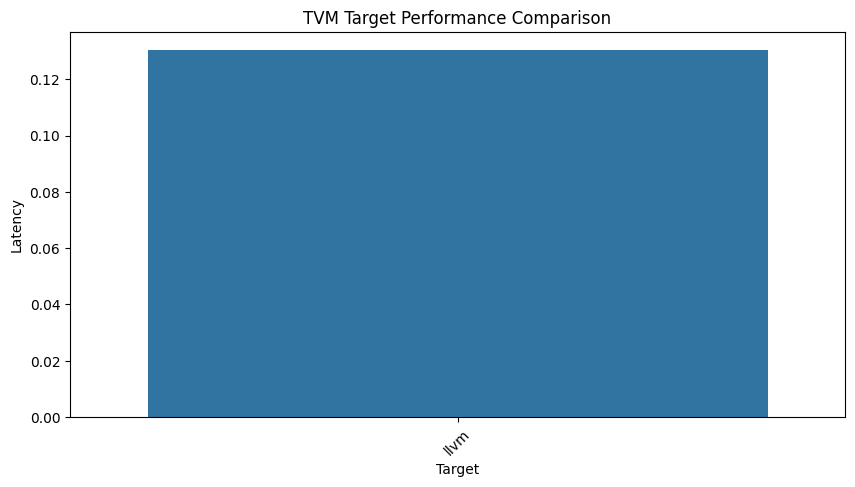

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.barplot(
    data=tvm_df,
    x="Target",
    y="Latency"
)

plt.title("TVM Target Performance Comparison")
plt.xticks(rotation=45)

plt.show()

In [66]:
best = tvm_df.loc[tvm_df["Latency"].idxmin()]

print("Best TVM Target:")
print(best)

Best TVM Target:
Target         llvm
Latency    0.130278
Name: 0, dtype: object


# **FINAL COMPARISON (ONNX vs TVM)**

In [67]:
comparison = pd.DataFrame({

    "Framework": [
        "ONNX Runtime",
        "TVM Best"
    ],

    "Latency": [
        onnx_time,
        tvm_df["Latency"].min()
    ]
})

comparison

,Framework,Latency
0,ONNX Runtime,0.038447
1,TVM Best,0.130278


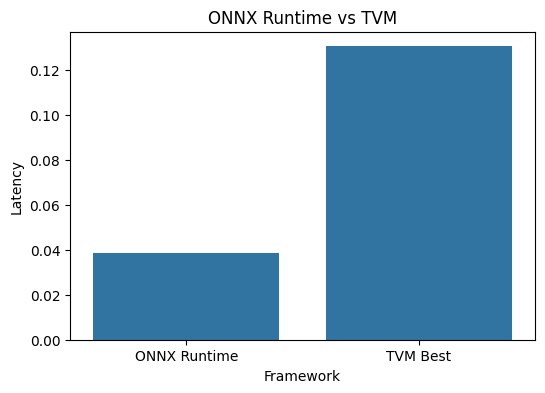

In [68]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=comparison,
    x="Framework",
    y="Latency"
)

plt.title("ONNX Runtime vs TVM")

plt.show()